In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.backends.backend_pdf import PdfPages

# Set style for plots
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10,6)

# Create folders if missing
os.makedirs("reports/figures", exist_ok=True)
os.makedirs("reports/pdf", exist_ok=True)

In [3]:
# Cell 2: Load the cleaned CSV
import pandas as pd
df = pd.read_csv("data/processed/cybersecurity_jobs.csv")
print(df)

                                 title           company  \
0  Associate Forward Deployed Engineer  Symmetry Systems   
1             Product Security Manager           MoonPay   
2              Cloud Security Engineer           MoonPay   
3  Senior Security Engineer Automation           MoonPay   
4               Associate Director CMC          Allucent   

                                        location  \
0                                         Remote   
1  United States (East Coast Time Zone) - Remote   
2                                            NaN   
3                                            NaN   
4                                            NaN   

                                              skills  
0  saas, security, training, technical, code, clo...  
1  security, manager, design, web3, crypto, syste...  
2  security, crypto, system, swift, training, tec...  
3  security, crypto, system, swift, training, tec...  
4  director, training, consulting, technical, sup..

In [4]:
df.head()

,title,company,location,skills
0,Associate Forward Deployed Engineer,Symmetry Systems,Remote,"saas, security, training, technical, code, clo..."
1,Product Security Manager,MoonPay,United States (East Coast Time Zone) - Remote,"security, manager, design, web3, crypto, syste..."
2,Cloud Security Engineer,MoonPay,NaN,"security, crypto, system, swift, training, tec..."
3,Senior Security Engineer Automation,MoonPay,NaN,"security, crypto, system, swift, training, tec..."
4,Associate Director CMC,Allucent,NaN,"director, training, consulting, technical, sup..."


In [5]:
# Cell 3: Top hiring companies
top_companies = df['company'].value_counts().head(10)
top_companies

company
MoonPay             3
Symmetry Systems    1
Allucent            1
Name: count, dtype: int64

C:\Users\Student\AppData\Local\Temp\ipykernel_9624\1647393995.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette='viridis')


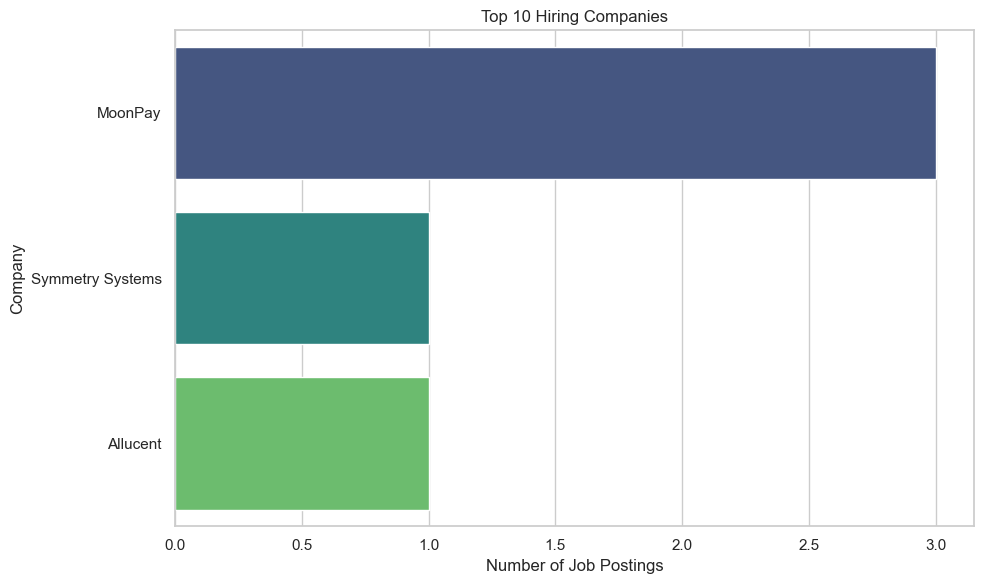

In [6]:
# Cell 4: Plot top hiring companies
plt.figure(figsize=(10,6))
sns.barplot(x=top_companies.values, y=top_companies.index, palette='viridis')
plt.title('Top 10 Hiring Companies')
plt.xlabel('Number of Job Postings')
plt.ylabel('Company')
plt.tight_layout()
plt.savefig("reports/figures/top_companies.png")
plt.show()

In [7]:
# Cell 5: Top requested skills
# Exploding skills column (comma separated)
df['skills_list'] = df['skills'].fillna('').str.split(',')
all_skills = df['skills_list'].explode().str.strip()
top_skills = all_skills.value_counts().head(15)
top_skills

skills_list
training      5
technical     5
management    5
security      4
cloud         4
lead          4
support       4
code          3
operations    3
engineer      3
crypto        3
system        3
voice         3
financial     3
healthcare    3
Name: count, dtype: int64

C:\Users\Student\AppData\Local\Temp\ipykernel_9624\3885555837.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skills.values, y=top_skills.index, palette='magma')


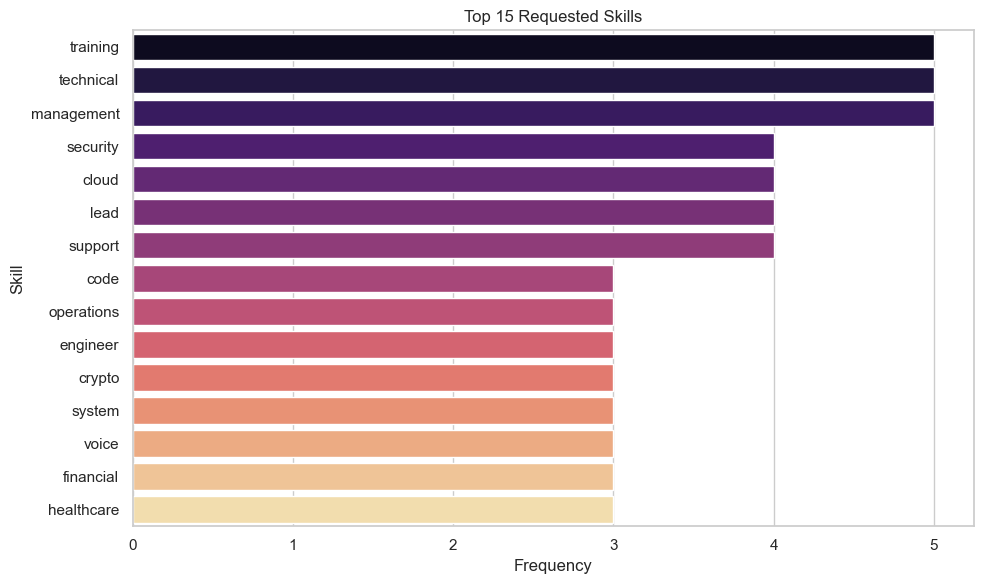

In [8]:
# Cell 6: Plot top skills
plt.figure(figsize=(10,6))
sns.barplot(x=top_skills.values, y=top_skills.index, palette='magma')
plt.title('Top 15 Requested Skills')
plt.xlabel('Frequency')
plt.ylabel('Skill')
plt.tight_layout()
plt.savefig("reports/figures/top_skills.png")
plt.show()

In [9]:
# Cell 7: Top job titles
top_titles = df['title'].value_counts().head(10)
top_titles

title
Associate Forward Deployed Engineer    1
Product Security Manager               1
Cloud Security Engineer                1
Senior Security Engineer Automation    1
Associate Director CMC                 1
Name: count, dtype: int64

C:\Users\Student\AppData\Local\Temp\ipykernel_9624\863594772.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_titles.values, y=top_titles.index, palette='cool')


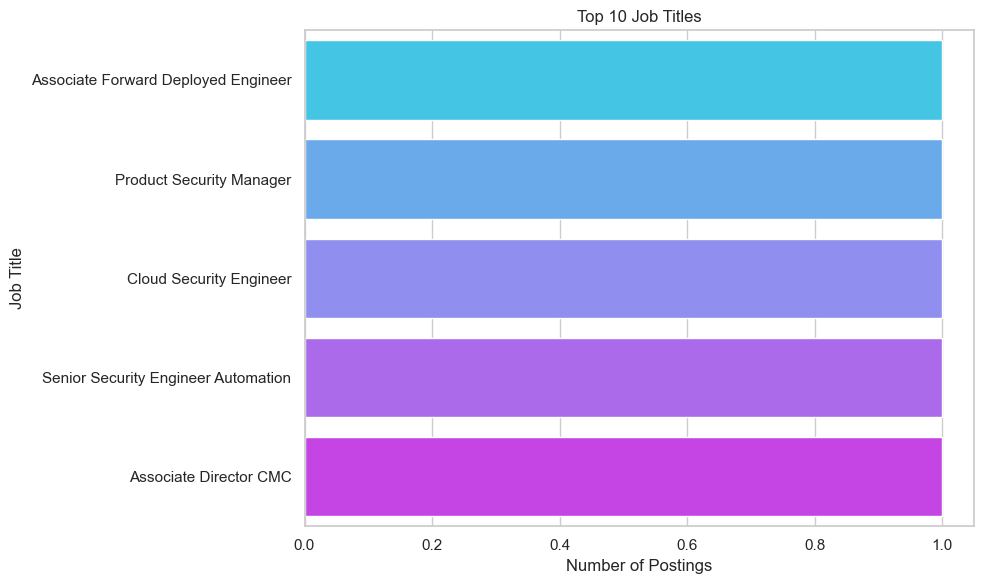

In [10]:
# Cell 8: Plot top job titles
plt.figure(figsize=(10,6))
sns.barplot(x=top_titles.values, y=top_titles.index, palette='cool')
plt.title('Top 10 Job Titles')
plt.xlabel('Number of Postings')
plt.ylabel('Job Title')
plt.tight_layout()
plt.savefig("reports/figures/top_titles.png")
plt.show()

In [11]:
# Cell 9: Save all charts into a single PDF
pdf_path = "reports/pdf/cyber_jobs_report.pdf"

with PdfPages(pdf_path) as pdf:
    for fig_file in ["reports/figures/top_companies.png",
                     "reports/figures/top_skills.png",
                     "reports/figures/top_titles.png"]:
        img = plt.imread(fig_file)
        plt.figure(figsize=(10,6))
        plt.imshow(img)
        plt.axis('off')
        pdf.savefig()
        plt.close()

print(f"PDF report saved at {pdf_path}")

PDF report saved at reports/pdf/cyber_jobs_report.pdf
